# Imports and Utils

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
os.chdir("/accounts/projects/jchayes/commnotes/analysis")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import statsmodels.formula.api as smf


from src.data_loader import *
from src.analysis import *
from src.visualization import *
from src.utils import *

In [5]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
PAPER_DATA_URL = "https://raw.githubusercontent.com/trenault/CommunityNotes/main/database_replication.csv"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"

WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


max_date = "2023-06-01"

In [6]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X
# I only kept the following columns "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2022-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorzation 
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)

history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
paper_df = pd.read_csv(PAPER_DATA_URL, dtype={'tweet_id': str})

# The following df is notes with corresponding topics. Topics are modelled by the X topic modeling algorithm.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv")
notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_3470782/3247873362.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Loading weekly outputs: 100%|██████████| 84/84 [01:17<00:00,  1.08it/s]


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


/tmp/ipykernel_3470782/3247873362.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [7]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

In [8]:
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

Loading weekly outputs: 100%|██████████| 44/44 [00:01<00:00, 28.09it/s]


note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [9]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})
note_df_full_2025 = note_df_full_2025.rename(columns={"internalNoteFactor1": "noteFactor1", "internalNoteIntercept": "noteIntercept"})

In [10]:
rollout_date = pd.to_datetime("2022-10-01")

In [11]:
# Ensure datetime
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtDate'])
first_rating = ratings_df.groupby('raterParticipantId')['createdAtDate'].min()
legacy_users = first_rating[first_rating < rollout_date].index.to_numpy()

new_users = first_rating[
    (first_rating >= rollout_date) & (first_rating < pd.to_datetime("2023-01-01"))
].index.to_numpy()

In [12]:
len(legacy_users), len(new_users)

(1202, 7177)

# Code Specs

In [65]:
ratings_df['createdAtDate'].min(), ratings_df['createdAtDate'].max()

(Timestamp('2022-06-01 00:00:44.565000'),
 Timestamp('2023-05-31 23:59:49.757000'))

In [66]:
ratings_df.columns

Index(['noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel',
       'createdAtDate'],
      dtype='object')

In [67]:
history_df.columns

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime'],
      dtype='object')

In [72]:
rater_df['week_dt'].min(), rater_df['week_dt'].max()

(Timestamp('2022-06-01 00:00:00'), Timestamp('2023-05-31 00:00:00'))

# Latent Factor Distribution Shift


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_2290808/3420194903.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2290808/3420194903.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


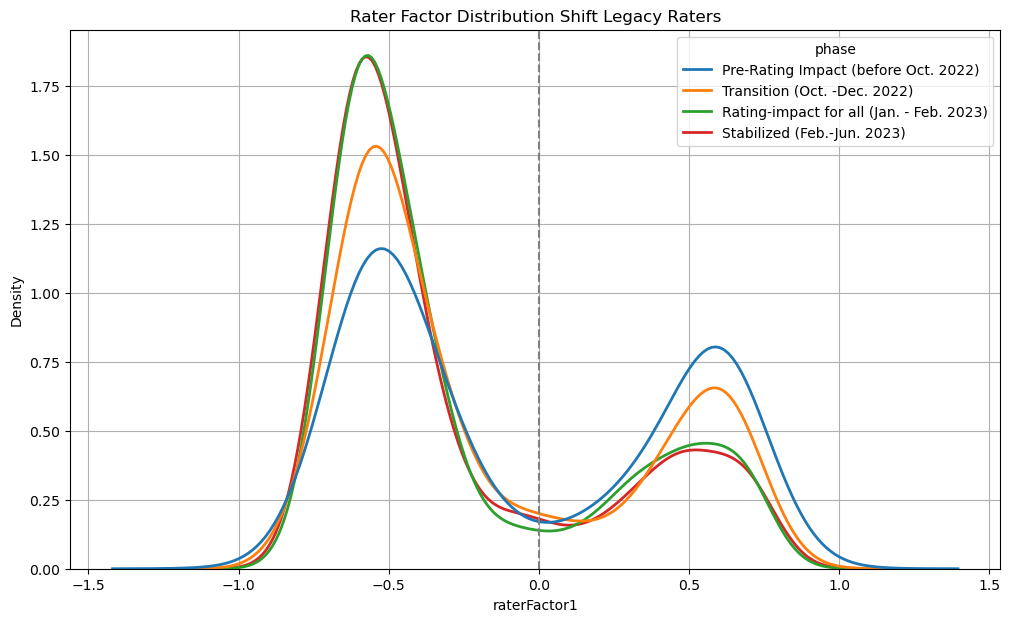

In [27]:
legacy_rater_df = rater_df[rater_df['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df['month_str'] = legacy_rater_df['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df['phase'] = legacy_rater_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df, 'raterFactor1', save_path='final_code/appendix-figures/rater_factor_distribution_shift_2022_legacy.png', title='Rater Factor Distribution Shift Legacy Raters')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_2290808/3994651521.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2290808/3994651521.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


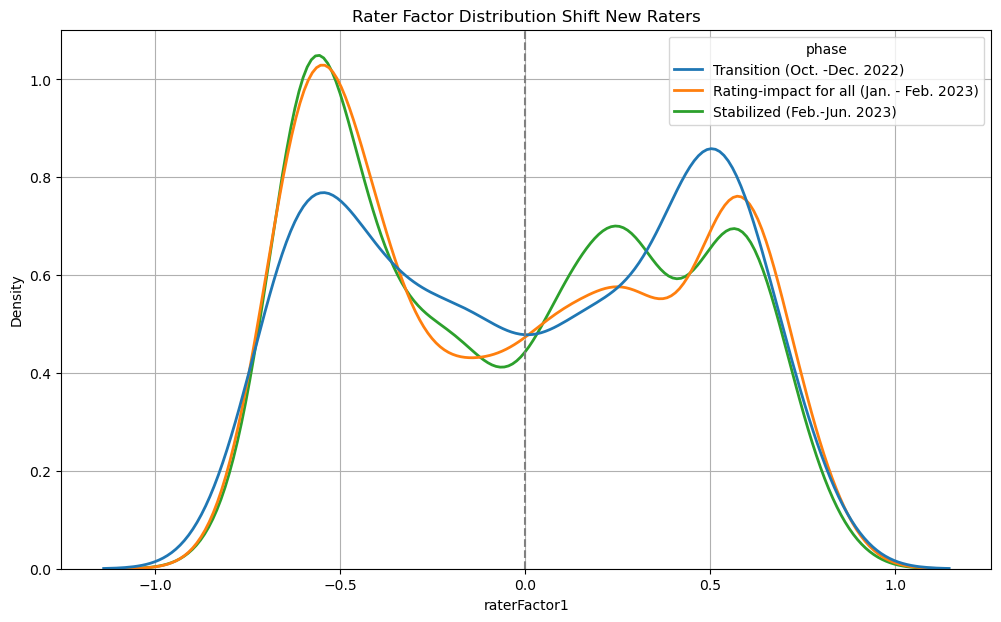

In [28]:
new_user_df = rater_df[rater_df['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_user_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_user_df['month_str'] = new_user_df['week_dt'].dt.strftime('%Y-%m')
new_user_df['phase'] = new_user_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_user_df, 'raterFactor1', save_path='final_code/appendix-figures/rater_factor_distribution_shift_2022_new.png', title='Rater Factor Distribution Shift New Raters')

In [62]:
def get_prop_pos_neg_by_phase(
    df,
    phase1='Transition (Oct. -Dec. 2022)',
    phase2='Stabilized (Feb.-Jun. 2023)',
    phase_col='phase',
    factor_col='raterFactor1'
):
    def props(d):
        s = d[factor_col].dropna()
        if s.empty:
            return np.nan, np.nan
        return (s < 0).mean(), (s > 0).mean()  # (prop_neg, prop_pos)

    d1 = df[df[phase_col] == phase1]
    d2 = df[df[phase_col] == phase2]

    prop_neg1, prop_pos1 = props(d1)
    prop_neg2, prop_pos2 = props(d2)

    return prop_neg1, prop_pos1, prop_neg2, prop_pos2


dfs = {'legacy_rater_df': legacy_rater_df, 'new_user_df': new_user_df}
dfs_2025 = {'legacy_rater_df_2025': legacy_rater_df_2025, 'new_rater_df_2025': new_rater_df_2025}

In [63]:
for df_name, d in dfs.items():
    pn1, pp1, pn2, pp2 = get_prop_pos_neg_by_phase(d)
    print(
        f"{df_name} | "
        f"phase1: prop_neg={pn1:.3f}, prop_pos={pp1:.3f} | "
        f"phase2: prop_neg={pn2:.3f}, prop_pos={pp2:.3f}"
    )

legacy_rater_df | phase1: prop_neg=0.686, prop_pos=0.314 | phase2: prop_neg=0.752, prop_pos=0.248
new_user_df | phase1: prop_neg=0.497, prop_pos=0.503 | phase2: prop_neg=0.505, prop_pos=0.495


In [64]:
for df_name, d in dfs_2025.items():
    pn1, pp1, pn2, pp2 = get_prop_pos_neg_by_phase(d)
    print(
        f"{df_name} | "
        f"phase1: prop_neg={pn1:.3f}, prop_pos={pp1:.3f} | "
        f"phase2: prop_neg={pn2:.3f}, prop_pos={pp2:.3f}"
    )

legacy_rater_df_2025 | phase1: prop_neg=0.692, prop_pos=0.308 | phase2: prop_neg=0.722, prop_pos=0.278
new_rater_df_2025 | phase1: prop_neg=0.512, prop_pos=0.488 | phase2: prop_neg=0.504, prop_pos=0.496



Pre-Rating Impact (before Oct. 2022)
  left peak  (x<0): -0.5766994824203635 density: 1.8541565595821572
  right peak (x>0): 0.5189025363156172 density: 0.4302329535740942

Transition (Oct. -Dec. 2022)
  left peak  (x<0): -0.5679625544665642 density: 1.8592429221784086
  right peak (x>0): 0.5536117229579276 density: 0.4544096534660684

Rating-impact for all (Jan. - Feb. 2023)
  left peak  (x<0): -0.5401771311265353 density: 1.530442456958096
  right peak (x>0): 0.5889430601629964 density: 0.6551085585969694

Stabilized (Feb.-Jun. 2023)
  left peak  (x<0): -0.5281152493896486 density: 1.1595478681425828
  right peak (x>0): 0.589698690267328 density: 0.8034418544297975


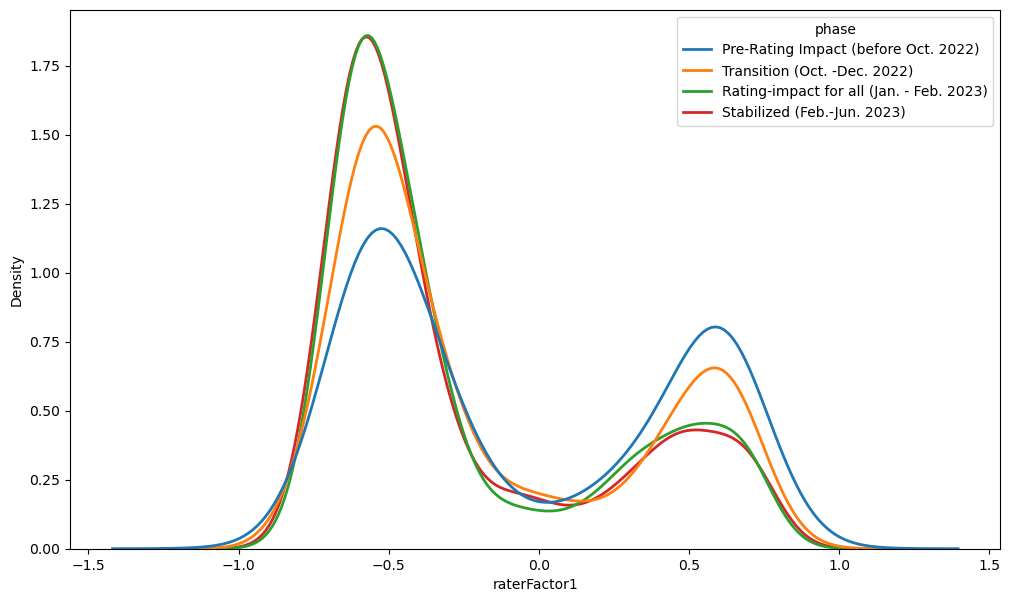

In [30]:
phase_order = [
    'Pre-Rating Impact (before Oct. 2022)',
    'Transition (Oct. -Dec. 2022)',
    'Rating-impact for all (Jan. - Feb. 2023)',
    'Stabilized (Feb.-Jun. 2023)'
]

# Always start a fresh figure/axes so you don't accidentally pick up old lines
fig, ax = plt.subplots(figsize=(12, 7))

ax = sns.kdeplot(
    data=legacy_rater_df,
    x='raterFactor1',
    hue='phase',
    hue_order=phase_order,
    common_norm=False,
    linewidth=2,
    ax=ax
)

# Build dict: phase -> (x, y) from the plotted lines
# Filter to "real" KDE lines (some matplotlib artists can sneak in)
lines = [ln for ln in ax.lines if len(ln.get_xdata()) > 10]
kde_xy = {phase: line.get_data() for phase, line in zip(phase_order, lines)}

def peak_on_side(x, y, side="left", split_at=0.0):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = (x < split_at) if side == "left" else (x > split_at)
    if not np.any(mask):
        return np.nan, np.nan
    xs, ys = x[mask], y[mask]
    i = np.argmax(ys)
    return xs[i], ys[i]

# Print peaks for every phase in kde_xy
for phase, (phase_x, phase_y) in kde_xy.items():
    x = np.asarray(phase_x)
    y = np.asarray(phase_y)

    left_mode_x, left_mode_y = peak_on_side(x, y, side="left", split_at=0.0)
    right_mode_x, right_mode_y = peak_on_side(x, y, side="right", split_at=0.0)

    print(f"\n{phase}")
    print("  left peak  (x<0):", left_mode_x, "density:", left_mode_y)
    print("  right peak (x>0):", right_mode_x, "density:", right_mode_y)


Pre-Rating Impact (before Oct. 2022)
  left peak  (x<0): -0.5563744384916399 density: 1.049238877707486
  right peak (x>0): 0.24283502830438897 density: 0.7004714209186693

Transition (Oct. -Dec. 2022)
  left peak  (x<0): -0.5535121815314854 density: 1.0291249105099582
  right peak (x>0): 0.5726185391194085 density: 0.7613993181386349

Rating-impact for all (Jan. - Feb. 2023)
  left peak  (x<0): -0.5426894235542515 density: 0.7686912451243041
  right peak (x>0): 0.5023227316141188 density: 0.8585524347300543


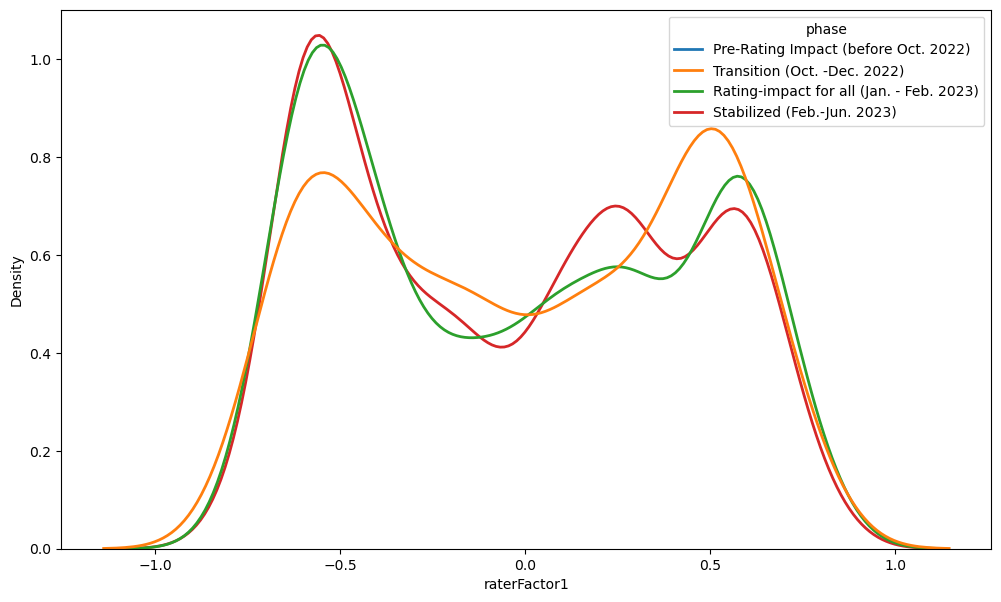

In [31]:
phase_order = [
    'Pre-Rating Impact (before Oct. 2022)',
    'Transition (Oct. -Dec. 2022)',
    'Rating-impact for all (Jan. - Feb. 2023)',
    'Stabilized (Feb.-Jun. 2023)'
]

# Always start a fresh figure/axes so you don't accidentally pick up old lines
fig, ax = plt.subplots(figsize=(12, 7))

ax = sns.kdeplot(
    data=new_user_df,
    x='raterFactor1',
    hue='phase',
    hue_order=phase_order,
    common_norm=False,
    linewidth=2,
    ax=ax
)

# Build dict: phase -> (x, y) from the plotted lines
# Filter to "real" KDE lines (some matplotlib artists can sneak in)
lines = [ln for ln in ax.lines if len(ln.get_xdata()) > 10]
kde_xy = {phase: line.get_data() for phase, line in zip(phase_order, lines)}
def peak_on_side(x, y, side="left", split_at=0.0):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = (x < split_at) if side == "left" else (x > split_at)
    if not np.any(mask):
        return np.nan, np.nan
    xs, ys = x[mask], y[mask]
    i = np.argmax(ys)
    return xs[i], ys[i]

# Print peaks for every phase in kde_xy
for phase, (phase_x, phase_y) in kde_xy.items():
    x = np.asarray(phase_x)
    y = np.asarray(phase_y)

    left_mode_x, left_mode_y = peak_on_side(x, y, side="left", split_at=0.0)
    right_mode_x, right_mode_y = peak_on_side(x, y, side="right", split_at=0.0)

    print(f"\n{phase}")
    print("  left peak  (x<0):", left_mode_x, "density:", left_mode_y)
    print("  right peak (x>0):", right_mode_x, "density:", right_mode_y)


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_2290808/815346212.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2290808/815346212.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


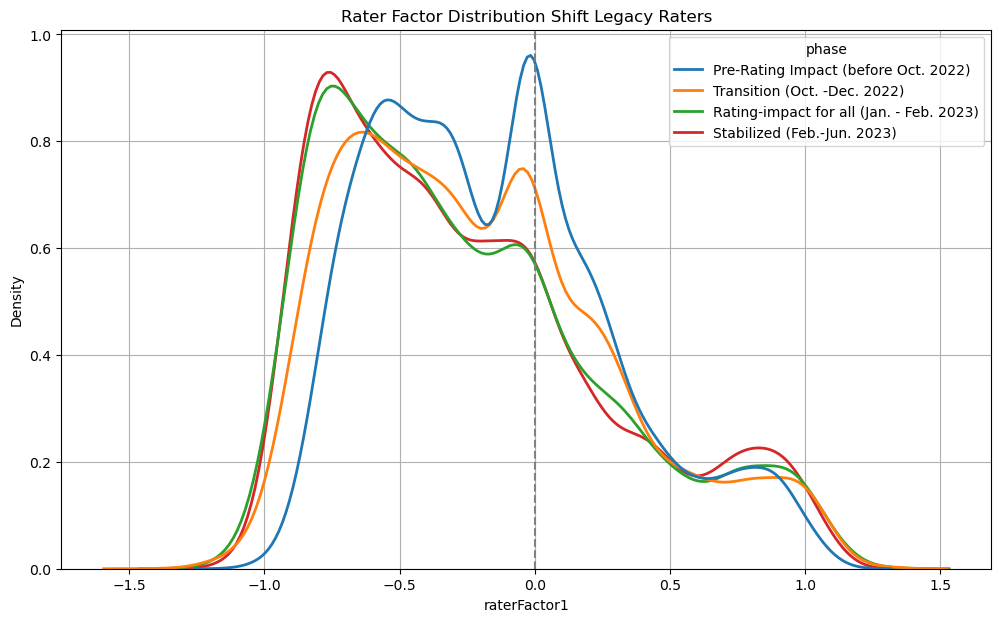

In [32]:
legacy_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df_2025['month_str'] = legacy_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df_2025['phase'] = legacy_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df_2025, 'raterFactor1', save_path='final_code/appendix-figures/rater_factor_distribution_shift_2025_legacy.png', title='Rater Factor Distribution Shift Legacy Raters')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_2290808/277908561.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2290808/277908561.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


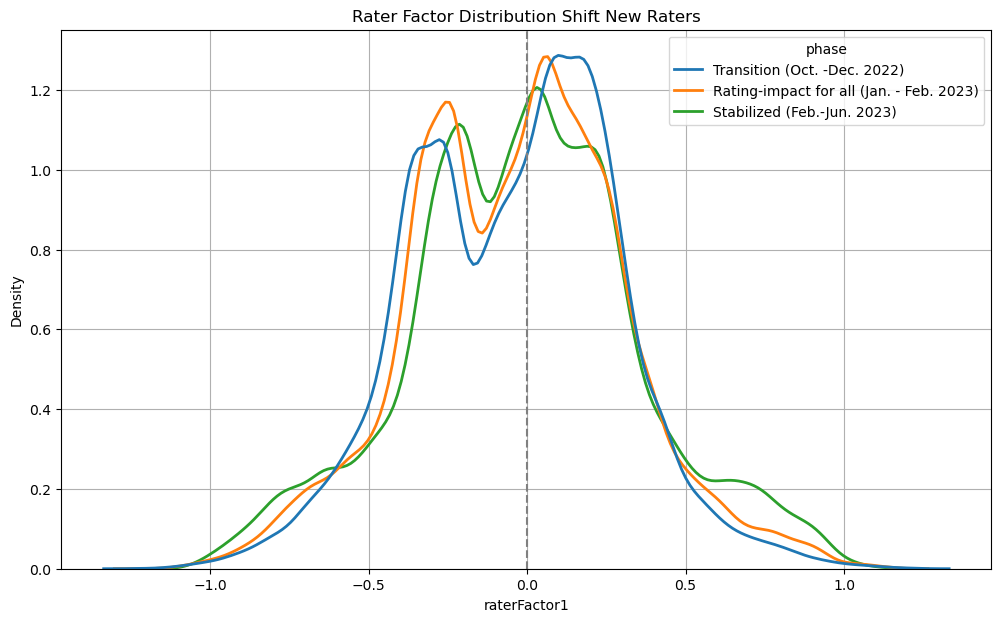

In [47]:
new_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_rater_df_2025['month_str'] = new_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
new_rater_df_2025['phase'] = new_rater_df_2025['month_str'].apply(assign_phase)
new_rater_df_2025 = new_rater_df_2025[new_rater_df_2025['phase'] != 'Pre-Rating Impact (before Oct. 2022)']
plot_factor_distribution_shifts(new_rater_df_2025, 'raterFactor1', save_path='final_code/appendix-figures/rater_factor_distribution_shift_2025_new.png', title='Rater Factor Distribution Shift New Raters')

In [45]:
user_first = (
    ratings_df.loc[ratings_df['raterParticipantId'] == test_user, 'createdAtDate']
    .min()
)
print(user_first)

2022-12-14 19:16:44.969000


In [43]:
new_rater_df_2025[new_rater_df_2025['raterParticipantId']== test_user]

,raterParticipantId,raterIntercept,raterFactor1,week,week_dt,month_str,phase
3,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.309488,0.445445,0,2022-08-01,2022-08,Pre-Rating Impact (before Oct. 2022)
1102,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.305560,0.456962,1,2022-08-08,2022-08,Pre-Rating Impact (before Oct. 2022)
2209,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.306683,0.494787,2,2022-08-15,2022-08,Pre-Rating Impact (before Oct. 2022)
3359,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.309879,0.503643,3,2022-08-22,2022-08,Pre-Rating Impact (before Oct. 2022)
4548,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.314313,0.496607,4,2022-08-29,2022-08,Pre-Rating Impact (before Oct. 2022)
5781,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.310976,0.538491,5,2022-09-05,2022-09,Pre-Rating Impact (before Oct. 2022)
7042,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.318080,0.479627,6,2022-09-12,2022-09,Pre-Rating Impact (before Oct. 2022)
8319,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.317821,0.476078,7,2022-09-19,2022-09,Pre-Rating Impact (before Oct. 2022)
9619,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.318493,0.477296,8,2022-09-26,2022-09,Pre-Rating Impact (before Oct. 2022)
10938,49E971702E686E509627B90D1AE85C2D6C9BFFF1BA79A2...,0.331000,0.487370,9,2022-10-03,2022-10,Transition (Oct. -Dec. 2022)


In [42]:
test_user = new_rater_df_2025[new_rater_df_2025['phase'] == 'Pre-Rating Impact (before Oct. 2022)']['raterParticipantId'].unique()[0]

# Bimodality Coefficient

In [13]:
def bimodality_coefficient(data):
    g = skew(data)
    k = kurtosis(data, fisher=False)
    if k == 0:
        return np.nan
    return (g**2 + 1) / k

def compute_bc_over_time(df, factor_col, week_col='week_dt'):
    bc_over_time = []
    weeks = sorted(df[week_col].dropna().unique())[1:]  # skip first week if needed
    for week in weeks:
        data = df[df[week_col] == week][factor_col].dropna()
        if len(data) > 1:
            bc = bimodality_coefficient(data)
            bc_over_time.append({week_col: week, 'bimodality_coefficient': bc})
    return pd.DataFrame(bc_over_time)

In [14]:
bc_rater_df = compute_bc_over_time(rater_df_2025, 'raterFactor1')
bc_note_df  = compute_bc_over_time(note_df_full_2025, 'noteFactor1')

In [26]:
def run_rdd_on_bimodality(bc_df, label, cutoff_date="2022-10-01", title="RDD on Bimodality Coefficient",
                          bandwidth_weeks=9):
    df = bc_df.copy()
    df['week_dt'] = pd.to_datetime(df['week_dt'])
    df = df.sort_values('week_dt')

    df['week_num'] = df['week_dt'].map(pd.Timestamp.toordinal)
    cutoff = pd.to_datetime(cutoff_date).toordinal()
    df['running'] = df['week_num'] - cutoff
    df['post'] = (df['running'] >= 0).astype(int)

    # Restrict to symmetric bandwidth
    bw_days = bandwidth_weeks * 7
    df = df[df['running'].between(-bw_days, bw_days)].copy()

    model = smf.ols('bimodality_coefficient ~ running + post + running:post', data=df).fit(cov_type='HC3')
    df['fitted'] = model.fittedvalues

    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x='week_dt', y='bimodality_coefficient', label='Observed', color='gray', s=50)
    sns.lineplot(data=df, x='week_dt', y='fitted', color='black', label='RDD Fit')
    plt.axvline(pd.to_datetime(cutoff_date), linestyle='--', color='red', label='Intervention')
    plt.title(f"{title} ({label.capitalize()} Factor)\nCutoff: {pd.to_datetime(cutoff_date).date()}, ±{bandwidth_weeks}-week window")
    plt.ylabel("Bimodality Coefficient")
    plt.xlabel("Week")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    save_path = f"final_code/appendix-figures/rdd_bimodality_coefficient_{label}_{cutoff_date}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Figure saved to {save_path}")
    print(model.summary())
    return df, model

In [23]:
cutoff = pd.to_datetime("2022-10-01")

for label, bc_df in [("rater", bc_rater_df), ("note", bc_note_df)]:
    df = bc_df.copy()
    df['week_dt'] = pd.to_datetime(df['week_dt'])
    pre  = df[df['week_dt'] < cutoff]
    post = df[df['week_dt'] >= cutoff]
    print(f"{label}: {len(pre)} pre-weeks ({pre['week_dt'].min().date()} → {pre['week_dt'].max().date()}), "
          f"{len(post)} post-weeks ({post['week_dt'].min().date()} → {post['week_dt'].max().date()})")

rater: 8 pre-weeks (2022-08-08 → 2022-09-26), 35 post-weeks (2022-10-03 → 2023-05-29)
note: 8 pre-weeks (2022-08-08 → 2022-09-26), 35 post-weeks (2022-10-03 → 2023-05-29)


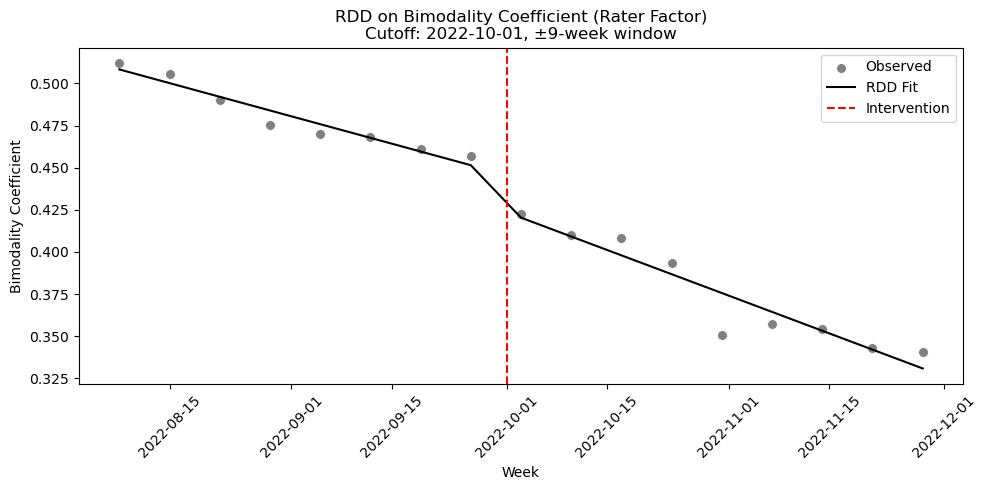

✅ Figure saved to final_code/appendix-figures/rdd_bimodality_coefficient_rater_2022-10-01.png
                              OLS Regression Results                              
Dep. Variable:     bimodality_coefficient   R-squared:                       0.981
Model:                                OLS   Adj. R-squared:                  0.976
Method:                     Least Squares   F-statistic:                     193.5
Date:                    Thu, 12 Mar 2026   Prob (F-statistic):           4.92e-11
Time:                            02:20:21   Log-Likelihood:                 57.786
No. Observations:                      17   AIC:                            -107.6
Df Residuals:                          13   BIC:                            -104.2
Df Model:                               3                                         
Covariance Type:                      HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.

/usr/local/linux/miniforge-3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.


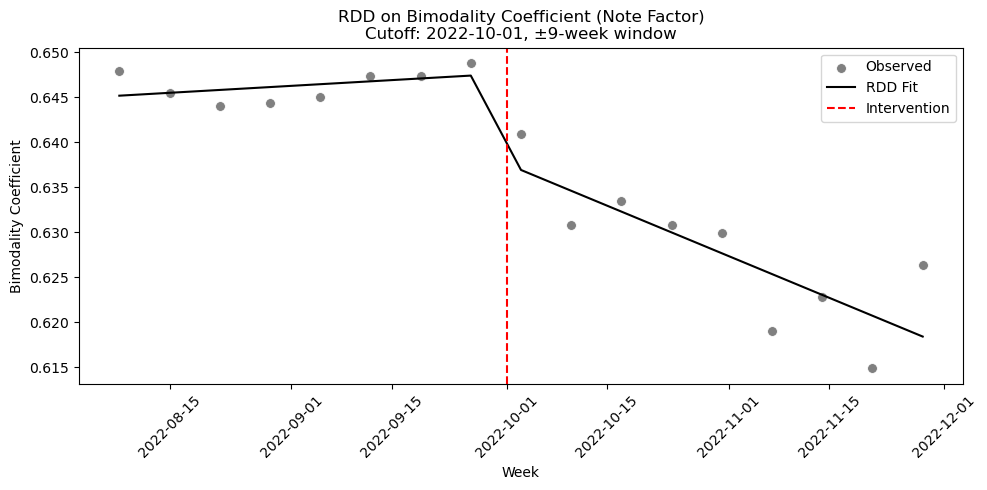

✅ Figure saved to final_code/appendix-figures/rdd_bimodality_coefficient_note_2022-10-01.png
                              OLS Regression Results                              
Dep. Variable:     bimodality_coefficient   R-squared:                       0.903
Model:                                OLS   Adj. R-squared:                  0.880
Method:                     Least Squares   F-statistic:                     27.16
Date:                    Thu, 12 Mar 2026   Prob (F-statistic):           7.18e-06
Time:                            02:20:22   Log-Likelihood:                 72.621
No. Observations:                      17   AIC:                            -137.2
Df Residuals:                          13   BIC:                            -133.9
Df Model:                               3                                         
Covariance Type:                      HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.9

/usr/local/linux/miniforge-3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.


In [27]:
# Run on rater bimodality
df_rater_rdd, model_rater = run_rdd_on_bimodality(
    bc_rater_df,
    label="rater",
    cutoff_date="2022-10-01",
    title="RDD on Bimodality Coefficient"
)

# Run on note bimodality
df_note_rdd, model_note = run_rdd_on_bimodality(
    bc_note_df,
    label="note",
    cutoff_date="2022-10-01",
    title="RDD on Bimodality Coefficient"
)

# DiD for Engagement Check
This is in the file topic_factor_shift.ipynb.

# Robustness for Controversial Topic Results

In [14]:
BOW_TOPIC_PATH = "/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv"
LLM_TOPIC_PATH = "/accounts/projects/jchayes/commnotes/notes_llm_topic.csv"

notes_bow_topic = pd.read_csv(BOW_TOPIC_PATH)
notes_llm_topic = pd.read_csv(LLM_TOPIC_PATH)

In [57]:
display(notes_df['noteId'].nunique(), notes_llm_topic['NOTEID'].nunique())

146401

1109313

In [58]:
notes_df['createdAtDate'] = pd.to_datetime(notes_df['createdAtMillis'], unit='ms')
print(notes_df['createdAtDate'].min(), notes_df['createdAtDate'].max())

2021-01-28 00:27:47.892000 2025-02-12 00:54:19.657000


In [61]:
notes_df_bow = notes_df.merge(notes_bow_topic[['noteId', 'noteTopic']], how='left', on='noteId')
notes_df_llm = notes_df.merge(notes_llm_topic, how='left', left_on='noteId', right_on='NOTEID')

In [67]:
bow_missing = notes_df_bow["noteTopic"].isna().mean() * 100
print(f"X topic modeller, percentage of notes missing topic: {bow_missing:.2f}%")

llm_missing = notes_df_llm["TOPIC"].isna().mean() * 100
print(f"TOPIC modeller, percentage of notes missing topic: {llm_missing:.2f}%")

llama_missing = notes_df_llm["LLAMA4"].isna().mean() * 100
print(f"LLAMA4 modeller, percentage of notes missing topic: {llama_missing:.2f}%")

X topic modeller, percentage of notes missing topic: 64.22%
TOPIC modeller, percentage of notes missing topic: 28.79%
LLAMA4 modeller, percentage of notes missing topic: 31.11%


In [68]:
notes_df_topic_all = notes_df_bow.merge(notes_llm_topic, how='left', left_on='noteId', right_on='NOTEID')

In [70]:
df = notes_with_topics_all.copy()

a, b, c = "noteTopic", "TOPIC", "LLAMA4"

# optional: normalize whitespace / blanks to NA (keeps internal spaces unless you remove them elsewhere)
for col in [a, b, c]:
    df[col] = df[col].astype("string").str.strip().replace({"": pd.NA})

df["agree_all3"] = (df[[a, b, c]].notna().all(axis=1) & df[a].eq(df[b]) & df[a].eq(df[c])).astype("int8")
df["agree_ab"]   = (df[[a, b]].notna().all(axis=1) & df[a].eq(df[b])).astype("int8")
df["agree_ac"]   = (df[[a, c]].notna().all(axis=1) & df[a].eq(df[c])).astype("int8")
df["agree_bc"]   = (df[[b, c]].notna().all(axis=1) & df[b].eq(df[c])).astype("int8")

notes_with_topics_all = df

In [76]:
n_total = len(df)

# denominators: only notes where the compared models all have a (non-missing) topic
den_all3 = df[[a, b, c]].notna().all(axis=1).sum()
den_ab   = df[[a, b]].notna().all(axis=1).sum()
den_ac   = df[[a, c]].notna().all(axis=1).sum()
den_bc   = df[[b, c]].notna().all(axis=1).sum()

num_all3 = df["agree_all3"].sum()
num_ab   = df["agree_ab"].sum()
num_ac   = df["agree_ac"].sum()
num_bc   = df["agree_bc"].sum()

print(
    f"All 3 agree: {num_all3}/{n_total} ({(num_all3/n_total)*100:.2f}%) | "
    f"{num_all3}/{den_all3} among non-missing ({(num_all3/den_all3)*100:.2f}%)"
)
print(
    f"{a} & {b} agree: {num_ab}/{n_total} ({(num_ab/n_total)*100:.2f}%) | "
    f"{num_ab}/{den_ab} among non-missing ({(num_ab/den_ab)*100:.2f}%)"
)
print(
    f"{a} & {c} agree: {num_ac}/{n_total} ({(num_ac/n_total)*100:.2f}%) | "
    f"{num_ac}/{den_ac} among non-missing ({(num_ac/den_ac)*100:.2f}%)"
)
print(
    f"{b} & {c} agree: {num_bc}/{n_total} ({(num_bc/n_total)*100:.2f}%) | "
    f"{num_bc}/{den_bc} among non-missing ({(num_bc/den_bc)*100:.2f}%)"
)

All 3 agree: 4129/146401 (2.82%) | 4129/37916 among non-missing (10.89%)
noteTopic & TOPIC agree: 4334/146401 (2.96%) | 4334/38686 among non-missing (11.20%)
noteTopic & LLAMA4 agree: 4157/146401 (2.84%) | 4157/38056 among non-missing (10.92%)
TOPIC & LLAMA4 agree: 74495/146401 (50.88%) | 74495/99894 among non-missing (74.57%)


In [75]:
notes_with_topics_all.head()

,noteId,summary,noteTopic,NOTEID,SUMMARY,TOPIC,LLAMA4,agree_all3,agree_ab,agree_ac,agree_bc
0,1783179305159200982,The House failed to pass a border protection l...,USPolitics,1.783179e+18,The House failed to pass a border protection l...,US Politics,US Politics,0,0,0,1
1,1783181538789605871,The United States has 50 States https://da...,<NA>,1.783182e+18,The United States has 50 States https://da...,US Politics,US Politics,0,0,0,1
2,1783182562279494134,TikTok only mentions “ban” and chooses to igno...,<NA>,1.783183e+18,TikTok only mentions “ban” and chooses to igno...,Tech Companies,Tech Companies,0,0,0,1
3,1883711635770196070,This could be considered a threat https://...,Scams,NaN,NaN,<NA>,<NA>,0,0,0,0
4,1537142913737428992,Forbes has a good rundown of the investigation...,USPolitics,1.537143e+18,Forbes has a good rundown of the investigation...,Crime Legal,US Politics,0,0,0,0


# Factor-Based Classification

In [29]:
# get the quantiles of the note distribution to label certain notes as controversial or not
# def label_controversial_notes(df, factor_col='noteFactor1', quantile=0.10):
#     df_labeled = df.copy()

#     low_cut = df_labeled[factor_col].quantile(quantile)
#     high_cut = df_labeled[factor_col].quantile(1 - quantile)

#     df_labeled['controversial'] = (
#         (df_labeled[factor_col] <= low_cut) | (df_labeled[factor_col] >= high_cut)
#     ).astype(int)

#     return df_labeled

In [98]:
def label_controversial_notes(df, factor_col='noteFactor1', quantile=0.10):
    df_labeled = df.copy()

    abs_cut = df_labeled[factor_col].abs().quantile(1 - 2 * quantile)

    df_labeled['controversial'] = (
        df_labeled[factor_col].abs() >= abs_cut
    ).astype(int)

    return df_labeled

In [101]:
# Compute factor scores using only pre-intervention data
pre_notes = note_df_full[note_df_full['week_dt'] < pd.to_datetime("2022-10-01")]
note_distribution_df = pre_notes.groupby('noteId')['noteFactor1'].mean().reset_index()

# Fit quantile cutoffs on pre-period only, then apply to all notes
pre_low  = note_distribution_df['noteFactor1'].quantile(0.10)
pre_high = note_distribution_df['noteFactor1'].quantile(0.90)

all_notes = note_df_full.groupby('noteId')['noteFactor1'].mean().reset_index()
all_notes['controversial'] = (
    (all_notes['noteFactor1'] <= pre_low) | (all_notes['noteFactor1'] >= pre_high)
).astype(int)
factor_q_df = all_notes
factor_q_df = factor_q_df.merge(notes_df[['noteId', 'tweetId']], on='noteId', how='left')

In [102]:
factor_q_df['controversial'].mean()

np.float64(0.44017632241813603)

In [103]:
# --- helpers ---------------------------------------------------------------
def _wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        phat = np.where(n > 0, k / n, np.nan)
        denom = 1 + z**2 / n
        center = (phat + (z**2) / (2*n)) / denom
        margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
        lo = center - margin
        hi = center + margin
    return lo, hi

def _weighted_centered_rolling(values, weights, window):
    """Centered, weight-aware rolling mean (nan-safe)."""
    s = pd.Series(values, dtype=float)
    w = pd.Series(weights, dtype=float)
    def _avg(x):
        v = x.values
        ww = w.iloc[x.index].values
        mask = ~np.isnan(v) & ~np.isnan(ww) & (ww > 0)
        return np.average(v[mask], weights=ww[mask]) if mask.any() else np.nan
    return s.rolling(window=window, center=True, min_periods=1).apply(_avg, raw=False)

In [104]:
# --- main calc -------------------------------------------------------------

def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # make sure both keys are the same dtype
    status_history_df = status_history_df.copy()
    notes_df = notes_df.copy()
    
    status_history_df["noteId"] = status_history_df["noteId"].astype("string")
    notes_df["noteId"] = notes_df["noteId"].astype("string")
    
    # Merge & prepare
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))
    
    print(df.columns)
    df['note_creation_dt'] = pd.to_datetime(df['createdAtMillis'], unit='ms')
    
    # --- ensure controversy flag and category labels ---
    df['controversial'] = pd.to_numeric(df['controversial'], errors='coerce').astype('Int64')
    
    df['topic_category'] = df['controversial'].map({
        1: 'Controversial',
        0: 'Non-Controversial'
    }).astype('string')

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby('tweetId')['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()
        unhelpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result

# --- plotting --------------------------------------------------------------

def plot_controversy_trends_principled(df: pd.DataFrame):
    """
    Plots smoothed, shrunken proportions with faint raw points and Wilson CIs.
    Points with denominator < min_n are hidden (NaN).
    """
    plt.figure(figsize=(15, 7))

    # find categories present
    cats = sorted({c.split('_')[-1] for c in df.columns if c.startswith('prop_helpful_smooth_')})

    for cat in cats:
        x = df['week_dt']
        # smoothed lines
        plt.plot(x, df[f'prop_helpful_smooth_{cat}'], label=f'Helpful: {cat}')
        plt.plot(x, df[f'prop_unhelpful_smooth_{cat}'], linestyle='--', label=f'Unhelpful: {cat}')

        # faint raw points (shrunken)
        plt.scatter(x, df[f'prop_helpful_shrunk_{cat}'], s=10, alpha=0.25)
        plt.scatter(x, df[f'prop_unhelpful_shrunk_{cat}'], s=10, alpha=0.25, marker='x')

        # optional CIs (light band) for helpful only to avoid clutter
        lo = df[f'prop_helpful_lo_{cat}']
        hi = df[f'prop_helpful_hi_{cat}']
        plt.fill_between(x, lo, hi, alpha=0.08)

    plt.title('Smoothed Proportion of Notes with Final Status by Topic Category (with CI)')
    plt.xlabel('Date')
    plt.ylabel('Proportion')
    plt.grid(True)
    plt.ylim([-0.01,.45])
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [105]:
p_df.head()

NameError: name 'p_df' is not defined

In [106]:
# --- usage -----------------------------------------------------------------
l_df, p_df = calculate_controversy_proportions_principled(history_df,
                                                    factor_q_df, 
                                                          time="W",
                                                    min_n=6, smooth_window=9)
# plot_controversy_trends_principled(p_df[p_df["week_dt"]<"2024-12"])

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime', 'noteFactor1',
       'controversial', 'tweetId'],
      dtype='object')



Summary of mean helpfulness and 95% CI (Wilson):
  Controversial |  Pre | mean = 0.143, 95% CI = [0.071, 0.267]
  Controversial | Post | mean = 0.080, 95% CI = [0.059, 0.107]
Non-Controversial |  Pre | mean = 0.131, 95% CI = [0.068, 0.238]
Non-Controversial | Post | mean = 0.265, 95% CI = [0.232, 0.302]
Figure saved to final_code/appendix-figures/factor_classification_pre_post_helpful_difference_2022-10-01.png


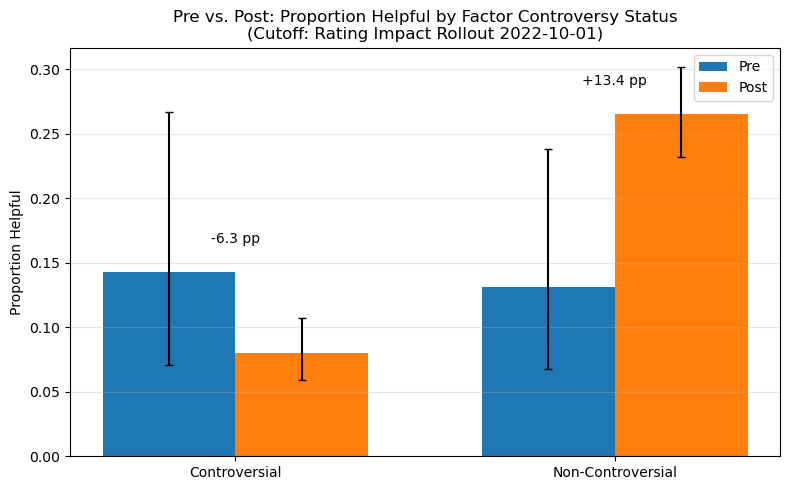

In [107]:
# --- utility: Wilson CI for aggregated counts ------------------------------
def wilson_ci_agg(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + (z**2) / (2*n)) / denom
    margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
    return center - margin, center + margin

# --- main: pre/post aggregated proportions + plot --------------------------
def plot_pre_post_helpful_difference(
    df_weekly: pd.DataFrame,
    cutoff_date: str = "2022-10-01",          # rollout date (YYYY-MM-DD)
    categories = ("Controversial", "Non-Controversial"),
    title = "Pre vs. Post: Proportion Helpful by Factor Controversy Status"
):
    """
    df_weekly: output of calculate_controversy_proportions_principled(...)
               must include columns:
               - 'week_dt'
               - 'denominator_tweets_{cat}'
               - 'helpful_{cat}'
    """
    cutoff = pd.to_datetime(cutoff_date)
    df = df_weekly.copy()
    df = df.sort_values("week_dt")
    df["period"] = np.where(df["week_dt"] < cutoff, "Pre", "Post")

    # aggregate counts by period and category
    rows = []
    for cat in categories:
        dcol = f"denominator_tweets_{cat}"
        hcol = f"helpful_{cat}"
        # guard for missing columns
        if dcol not in df.columns or hcol not in df.columns:
            raise KeyError(f"Expected columns '{dcol}' and '{hcol}' not found in dataframe.")
        for period, g in df.groupby("period"):
            n = np.nansum(g[dcol].values)
            k = np.nansum(g[hcol].values)
            p = (k / n) if n > 0 else np.nan
            lo, hi = wilson_ci_agg(k, n)
            rows.append({
                "category": cat,
                "period": period,
                "k_helpful": k,
                "n_den": n,
                "prop_helpful": p,
                "ci_lo": lo,
                "ci_hi": hi
            })
    agg = pd.DataFrame(rows)

    print("\nSummary of mean helpfulness and 95% CI (Wilson):")
    for cat in categories:
        for period in ["Pre", "Post"]:
            row = agg[(agg["category"] == cat) & (agg["period"] == period)]
            if not row.empty:
                p = row["prop_helpful"].values[0]
                lo = row["ci_lo"].values[0]
                hi = row["ci_hi"].values[0]
                print(f"{cat:>15} | {period:>4} | mean = {p:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]")

    # compute change (Post - Pre) for label
    change = (
        agg.pivot(index="category", columns="period", values="prop_helpful")
           .assign(change=lambda x: x["Post"] - x["Pre"])
           .reset_index()
    )

    # plot grouped bars with error bars
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(categories))
    width = 0.35

    pre = agg[agg["period"] == "Pre"].set_index("category").loc[list(categories)]
    post = agg[agg["period"] == "Post"].set_index("category").loc[list(categories)]

    pre_bars = ax.bar(x - width/2, pre["prop_helpful"].values, width,
                      yerr=[pre["prop_helpful"].values - pre["ci_lo"].values,
                            pre["ci_hi"].values - pre["prop_helpful"].values],
                      capsize=3, label="Pre")
    post_bars = ax.bar(x + width/2, post["prop_helpful"].values, width,
                       yerr=[post["prop_helpful"].values - post["ci_lo"].values,
                             post["ci_hi"].values - post["prop_helpful"].values],
                       capsize=3, label="Post")

    # add change labels (in percentage points) above the pairs
    for i, cat in enumerate(categories):
        delta = change.loc[change["category"] == cat, "change"].values[0]
        if pd.notnull(delta):
            y = max(pre["prop_helpful"].values[i], post["prop_helpful"].values[i])
            ax.text(x[i], y + 0.02, f"{delta*100:+.1f} pp", ha="center", va="bottom")

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    # ax.set_ylim(0, 1.05)
    ax.set_ylabel("Proportion Helpful")
    ax.set_title(title + f"\n(Cutoff: Rating Impact Rollout {pd.to_datetime(cutoff_date).date()})")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    save_path = f"final_code/appendix-figures/factor_classification_pre_post_helpful_difference_{cutoff_date}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved to {save_path}")
    
    plt.show()

plot_pre_post_helpful_difference(p_df[(p_df["week_dt"]<"2023-03-01")&(p_df["week_dt"]>"2022-06-01")], cutoff_date="2022-10-01")

In [48]:
def _prepare_long_from_panel(panel_df, treated="Non-Controversial", control="Controversial",
                             min_n=30, use_jeffreys=True):
    """
    Returns long df with one row per (week, topic): week_dt, topic_type, prop, n_raw.
    prop uses Jeffreys smoothing for stability; n_raw is the raw denominator for weights.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    out = []
    for topic in (treated, control):
        k_raw = df[f"helpful_{topic}"].astype(float)
        n_raw = df[f"denominator_tweets_{topic}"].astype(float)

        # Smoothed proportion for stability, but keep RAW n for weights
        if use_jeffreys:
            k = k_raw + 0.5
            n = n_raw + 1.0
        else:
            k, n = k_raw, n_raw

        prop = np.where(n_raw > 0, k / n, np.nan)
        keep = (n_raw >= min_n) & np.isfinite(prop)

        out.append(pd.DataFrame({
            "week_dt": df["week_dt"],
            "topic_type": topic,
            "prop": pd.Series(prop).where(keep),
            "n_raw": n_raw.where(keep)
        }))

    long_df = pd.concat(out, ignore_index=True).dropna(subset=["prop", "n_raw"])
    return long_df


def _weekly_diff_series(long_df, treated, control, weight_mode="min"):
    """
    Balanced weekly difference series:
      diff_t = prop_treated_t - prop_control_t
      w_t    = min(n_treated_t, n_control_t) or sum(...), per weight_mode.
    """
    wide = long_df.pivot(index="week_dt", columns="topic_type", values=["prop", "n_raw"])
    props = wide["prop"]
    ns = wide["n_raw"]

    if treated not in props or control not in props:
        raise ValueError("After filtering, one of the topics is missing. Check names and min_n.")

    # Keep only weeks where both are observed
    diff = (props[treated] - props[control]).dropna()
    n_t = ns[treated].reindex(diff.index)
    n_c = ns[control].reindex(diff.index)

    if weight_mode == "sum":
        w = (n_t + n_c).astype(float)
    else:  # default "min"
        w = np.minimum(n_t, n_c).astype(float)

    w = w.clip(lower=1.0)

    series = pd.DataFrame({"diff": diff.astype(float), "w": w.astype(float)})
    series.index.name = "week_dt"
    return series


def _fit_window(y, w, is_post, hac_maxlags=4):
    """
    WLS diff-in-means (pre vs post) with HAC standard errors.
    y, w, is_post can be numpy arrays or pandas Series.
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    is_post = np.asarray(is_post, dtype=float)

    X = sm.add_constant(is_post)
    fit = sm.WLS(y, X, weights=w).fit(cov_type="HAC", cov_kwds={"maxlags": hac_maxlags})

    est = float(fit.params[1])
    se = float(fit.bse[1])
    p = float(fit.pvalues[1])
    z = 1.96
    ci = (est - z * se, est + z * se)
    return {"est": est, "se": se, "ci": ci, "p": p}


def did_windows_v2(panel_df,
                   change_date="2022-12-15",
                   treated="Non-Controversial",
                   control="Controversial",
                   pre_weeks=8,
                   short_post_weeks=8,
                   medium_post_weeks=(9, 26),
                   min_n=30,
                   use_jeffreys=True,
                   weight_mode="min",
                   hac_maxlags=4):
    """
    Short- and medium-run DiD on weekly helpfulness differences.
    Returns dict with 'short', 'medium', 'series', and 'meta'.
    """
    # Build balanced weekly diff series
    long_df = _prepare_long_from_panel(panel_df, treated, control, min_n, use_jeffreys)
    series = _weekly_diff_series(long_df, treated, control, weight_mode)
    series = series.sort_index()
    change_dt = pd.to_datetime(change_date)

    weeks = series.index

    # Pre window: last `pre_weeks` weeks strictly before the change
    pre_weeks_idx = weeks[weeks < change_dt]
    pre_weeks_idx = pre_weeks_idx[-pre_weeks:]  # if fewer exist, we take all available

    # Short post: from change_dt inclusive, take the next `short_post_weeks` observed weeks
    short_post_all = weeks[weeks >= change_dt]
    short_idx = short_post_all[:short_post_weeks]

    # Medium post: (lo, hi) weeks after change (inclusive)
    m_lo, m_hi = medium_post_weeks
    med_start = change_dt + pd.Timedelta(weeks=m_lo)
    med_end = change_dt + pd.Timedelta(weeks=m_hi)
    med_idx = weeks[(weeks >= med_start) & (weeks <= med_end)]

    def _run_window(idx_post):
        # aligned boolean masks (as Series) to avoid reindex warnings
        pre_mask = pd.Series(series.index.isin(pre_weeks_idx), index=series.index)
        post_mask = pd.Series(series.index.isin(idx_post), index=series.index)
        keep = pre_mask | post_mask

        y = series.loc[keep, "diff"]
        w = series.loc[keep, "w"]
        is_post = post_mask.loc[keep]

        # guard rails
        if y.size < 4 or is_post.sum() == 0 or (~is_post).sum() == 0:
            return {
                "est": np.nan, "se": np.nan, "ci": (np.nan, np.nan), "p": np.nan,
                "n_pre": int((~is_post).sum()), "n_post": int(is_post.sum()),
                "weeks_pre": list(pre_weeks_idx.astype(str)),
                "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
            }

        out = _fit_window(y.to_numpy(), w.to_numpy(), is_post.to_numpy(), hac_maxlags=hac_maxlags)
        out.update({
            "n_pre": int((~is_post).sum()),
            "n_post": int(is_post.sum()),
            "weeks_pre": list(pre_weeks_idx.astype(str)),
            "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
        })
        return out

    short_res = _run_window(short_idx)
    medium_res = _run_window(med_idx)

    return {
        "short": short_res,
        "medium": medium_res,
        "series": series.reset_index(),  # columns: week_dt, diff, w
        "meta": {
            "change_date": str(pd.to_datetime(change_date).date()),
            "pre_weeks": pre_weeks,
            "short_post_weeks": short_post_weeks,
            "medium_post_weeks": medium_post_weeks,
            "min_n": min_n,
            "weight_mode": weight_mode,
            "use_jeffreys": use_jeffreys,
            "hac_maxlags": hac_maxlags,
            "treated": treated,
            "control": control,
        },
    }


In [56]:
res = did_windows_v2(
    p_df,
    change_date="2022-10-01",
    treated="Non-Controversial",
    control="Controversial",
    pre_weeks=14,                # short-run baseline window
    short_post_weeks=14,          # short-run post
    medium_post_weeks=(14, 28),   # medium-run post
    min_n=1,                    # require both groups to have ≥1 tweets that week
    use_jeffreys=True,
    weight_mode="min",           # or "sum"
    hac_maxlags=4
)

print(res["short"])    # dict: est, se, ci, p, n_pre, n_post, weeks_pre, weeks_post
print(res["medium"])   # same for the medium window
res["series"].head() 

{'est': 0.13818552646693455, 'se': 0.06390493323979105, 'ci': (0.012931857316944101, 0.26343919561692497), 'p': 0.030590371922680507, 'n_pre': 14, 'n_post': 14, 'weeks_pre': ['2022-06-19', '2022-06-26', '2022-07-03', '2022-07-10', '2022-07-24', '2022-07-31', '2022-08-07', '2022-08-14', '2022-08-21', '2022-08-28', '2022-09-04', '2022-09-11', '2022-09-18', '2022-09-25'], 'weeks_post': ['2022-10-02', '2022-10-09', '2022-10-16', '2022-10-23', '2022-10-30', '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27', '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25', '2023-01-01']}
{'est': 0.2389075740390632, 'se': 0.04365744880301877, 'ci': (0.15333897438514643, 0.32447617369298), 'p': 4.4417931552647946e-08, 'n_pre': 14, 'n_post': 9, 'weeks_pre': ['2022-06-19', '2022-06-26', '2022-07-03', '2022-07-10', '2022-07-24', '2022-07-31', '2022-08-07', '2022-08-14', '2022-08-21', '2022-08-28', '2022-09-04', '2022-09-11', '2022-09-18', '2022-09-25'], 'weeks_post': ['2023-01-08', '2023-01-15', '2023

,week_dt,diff,w
0,2021-08-29,0.291667,3.0
1,2021-09-05,-0.202381,5.0
2,2021-09-12,0.250000,2.0
3,2021-09-19,-0.083333,1.0
4,2021-09-26,0.000000,1.0


# Two-Sample Tests for Rating Proportions Before vs. After
The goal of this section of code is to compare the proportion of ratings assigned to controversial vs. non-controversial notes before and after the rating impact rollout. The hypothesis is that the proportion is the same.

In [ ]:
# note dataframes
# notes_bow_topic = pd.read_csv(BOW_TOPIC_PATH)
# notes_llm_topic = pd.read_csv(LLM_TOPIC_PATH)

In [76]:
# notes_df.head()

notes_llm_topic['TOPIC'] = notes_llm_topic['TOPIC'].str.replace(' ', '', regex=False)
notes_llm_topic['LLAMA4'] = notes_llm_topic['LLAMA4'].str.replace(' ', '', regex=False)


notes_with_topic_all = notes_df.merge(notes_bow_topic[['noteId', 'noteTopic']], on='noteId', how='left')
notes_with_topic_all = notes_with_topic_all.merge(notes_llm_topic[['NOTEID', 'TOPIC', 'LLAMA4']], left_on='noteId', right_on='NOTEID', how='left')

In [77]:
CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

notes_with_topic_all["controversial"] = np.select(
    [
        notes_with_topic_all['noteTopic'].isin(CONTROVERSIAL_TOPICS),
        notes_with_topic_all['noteTopic'].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    [1, 0],
    default=pd.NA,
)

In [78]:
ratings_with_topic = ratings_df.merge(notes_with_topic_all[['noteId', 'noteTopic', 'TOPIC', 'LLAMA4', 'controversial']], on='noteId', how='left')
ratings_with_topic.head()

,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,createdAtDate,noteTopic,TOPIC,LLAMA4,controversial
0,1605704964017225728,26F1AE5A1229F1F16AB1EDE3215470DE9904BFA9E3089B...,1671695590604,HELPFUL,2022-12-22 07:53:10.604,HealthCovid,UkraineConflict,UkraineConflict,1
1,1652068616592842755,26F1AE5A1229F1F16AB1EDE3215470DE9904BFA9E3089B...,1682755317339,HELPFUL,2023-04-29 08:01:57.339,NaN,NaN,NaN,NaN
2,1652137397952430081,26F1AE5A1229F1F16AB1EDE3215470DE9904BFA9E3089B...,1682770958208,HELPFUL,2023-04-29 12:22:38.208,NaN,NaN,NaN,NaN
3,1663592995927490575,27B53A683739DAE26EE9B7482EEE565CD6669920F9CA0B...,1685485011919,HELPFUL,2023-05-30 22:16:51.919,NaN,NaN,NaN,NaN
4,1590463688397430784,8CBABFD2DF1850C3672B5465693297A23D11B3A6D1F616...,1673054472662,HELPFUL,2023-01-07 01:21:12.662,NaN,NaN,NaN,NaN


In [79]:
cutoff_date = '2022-10-01'
end_date = pd.Timestamp(cutoff_date) + pd.Timedelta(weeks=12)

In [80]:
# drop NaN
ratings_with_topic_clean = ratings_with_topic
# ratings_with_topic_clean = ratings_with_topic.dropna(subset=['controversial'])
ratings_with_topic_clean['controversial'] = pd.to_numeric(ratings_with_topic_clean['controversial'], errors='coerce')

In [81]:
ratings_with_topic_clean.head()

,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,createdAtDate,noteTopic,TOPIC,LLAMA4,controversial
0,1605704964017225728,26F1AE5A1229F1F16AB1EDE3215470DE9904BFA9E3089B...,1671695590604,HELPFUL,2022-12-22 07:53:10.604,HealthCovid,UkraineConflict,UkraineConflict,1.0
1,1652068616592842755,26F1AE5A1229F1F16AB1EDE3215470DE9904BFA9E3089B...,1682755317339,HELPFUL,2023-04-29 08:01:57.339,NaN,NaN,NaN,NaN
2,1652137397952430081,26F1AE5A1229F1F16AB1EDE3215470DE9904BFA9E3089B...,1682770958208,HELPFUL,2023-04-29 12:22:38.208,NaN,NaN,NaN,NaN
3,1663592995927490575,27B53A683739DAE26EE9B7482EEE565CD6669920F9CA0B...,1685485011919,HELPFUL,2023-05-30 22:16:51.919,NaN,NaN,NaN,NaN
4,1590463688397430784,8CBABFD2DF1850C3672B5465693297A23D11B3A6D1F616...,1673054472662,HELPFUL,2023-01-07 01:21:12.662,NaN,NaN,NaN,NaN


In [82]:
pre_ratings = ratings_with_topic_clean[ratings_with_topic_clean['createdAtDate'] < cutoff_date]
post_ratings = ratings_with_topic_clean[(ratings_with_topic_clean['createdAtDate'] > cutoff_date) & (ratings_with_topic_clean['createdAtDate'] < end_date)]

In [83]:
display(pre_ratings.shape, post_ratings.shape)

(14042, 9)

(65188, 9)

In [88]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Count all three categories in each period
pre_counts = pre_ratings['controversial'].value_counts(dropna=False)
post_counts = post_ratings['controversial'].value_counts(dropna=False)

# Align both periods to have the same categories (fills 0 if a category is missing)
categories = [0, 1, np.nan]  # adjust labels to match your actual values
pre_controversial    = (pre_ratings['controversial'] == 1).sum()
pre_non_controversial = (pre_ratings['controversial'] == 0).sum()
pre_nan              = pre_ratings['controversial'].isna().sum()

post_controversial    = (post_ratings['controversial'] == 1).sum()
post_non_controversial = (post_ratings['controversial'] == 0).sum()
post_nan              = post_ratings['controversial'].isna().sum()

# Build 2x3 contingency table
contingency_table = np.array([
    [pre_controversial, pre_non_controversial, pre_nan],
    [post_controversial, post_non_controversial, post_nan]
])

print("=== Contingency Table ===")
df_table = pd.DataFrame(
    contingency_table,
    index=['Pre', 'Post'],
    columns=['Controversial', 'Non-Controversial', 'NaN']
)
print(df_table)
print()

# Row proportions to see the distribution shift
print("=== Row Proportions ===")
print(df_table.div(df_table.sum(axis=1), axis=0).round(4))
print()

# Chi-square test
chi2, pvalue, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared: {chi2:.4f}")
print(f"P-value:     {pvalue:.4f}")
print(f"Degrees of freedom: {dof}")

=== Contingency Table ===
      Controversial  Non-Controversial    NaN
Pre            1540                177  12325
Post           5469                946  58773

=== Row Proportions ===
      Controversial  Non-Controversial     NaN
Pre          0.1097             0.0126  0.8777
Post         0.0839             0.0145  0.9016

Chi-squared: 97.0633
P-value:     0.0000
Degrees of freedom: 2


In [70]:
for topic_col in ['noteTopic', 'TOPIC', 'LLAMA4']:
    notes_with_topic_all["controversial"] = np.select(
        [
            notes_with_topic_all[topic_col].isin(CONTROVERSIAL_TOPICS),
            notes_with_topic_all[topic_col].isin(NON_CONTROVERSIAL_TOPICS),
        ],
        [1, 0],
        default=pd.NA,
    )

    ratings_with_topic = ratings_df.merge(
        notes_with_topic_all[['noteId', topic_col, 'controversial']],
        on='noteId', how='left'
    )
    ratings_with_topic_clean = ratings_with_topic.dropna(subset=['controversial'])
    ratings_with_topic_clean['controversial'] = pd.to_numeric(ratings_with_topic_clean['controversial'], errors='coerce')

    pre_ratings = ratings_with_topic_clean[ratings_with_topic_clean['createdAtDate'] < cutoff_date]
    post_ratings = ratings_with_topic_clean[(ratings_with_topic_clean['createdAtDate'] > cutoff_date) & (ratings_with_topic_clean['createdAtDate'] < end_date)]

    pre_controversial = pre_ratings['controversial'].sum()
    post_controversial = post_ratings['controversial'].sum()
    pre_total = len(pre_ratings)
    post_total = len(post_ratings)

    stat, pvalue = proportions_ztest([pre_controversial, post_controversial], [pre_total, post_total])

    print(f"\n--- Topic column: {topic_col} ---")
    print(f"Z-statistic: {stat:.4f}")
    print(f"P-value: {pvalue:.4f}")
    print(f"Pre controversial rate:  {pre_controversial / pre_total:.3f}")
    print(f"Post controversial rate: {post_controversial / post_total:.3f}")

/tmp/ipykernel_3470782/3759661465.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3470782/3759661465.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



--- Topic column: noteTopic ---
Z-statistic: 4.7343
P-value: 0.0000
Pre controversial rate:  0.897
Post controversial rate: 0.853

--- Topic column: TOPIC ---
Z-statistic: 20.9315
P-value: 0.0000
Pre controversial rate:  0.756
Post controversial rate: 0.535

--- Topic column: LLAMA4 ---
Z-statistic: 27.2595
P-value: 0.0000
Pre controversial rate:  0.783
Post controversial rate: 0.495


/tmp/ipykernel_3470782/3759661465.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [93]:
from scipy.stats import fisher_exact

In [97]:
for topic_col in ['noteTopic', 'TOPIC', 'LLAMA4']:
    notes_with_topic_all["controversial"] = np.select(
        [
            notes_with_topic_all[topic_col].isin(CONTROVERSIAL_TOPICS),
            notes_with_topic_all[topic_col].isin(NON_CONTROVERSIAL_TOPICS),
        ],
        [1, 0],
        default=pd.NA,
    )
    ratings_with_topic = ratings_df.merge(
        notes_with_topic_all[['noteId', topic_col, 'controversial']],
        on='noteId', how='left'
    )

    ratings_with_topic_clean = ratings_with_topic.dropna(subset=['controversial'])
    ratings_with_topic_clean['controversial'] = pd.to_numeric(ratings_with_topic_clean['controversial'], errors='coerce')

    pre_ratings  = ratings_with_topic_clean[ratings_with_topic_clean['createdAtDate'] < cutoff_date]
    post_ratings = ratings_with_topic_clean[(ratings_with_topic_clean['createdAtDate'] > cutoff_date) & (ratings_with_topic_clean['createdAtDate'] < end_date)]

    pre_con  = int(pre_ratings['controversial'].sum())
    pre_non  = int((pre_ratings['controversial'] == 0).sum())
    post_con = int(post_ratings['controversial'].sum())
    post_non = int((post_ratings['controversial'] == 0).sum())

    odds_ratio, p_fisher = fisher_exact(np.array([[pre_con, pre_non], [post_con, post_non]]))

    print(f"\n--- {topic_col} ---")
    print(f"Pre:  {pre_con}/{pre_con+pre_non} controversial ({pre_con/(pre_con+pre_non):.3f})")
    print(f"Post: {post_con}/{post_con+post_non} controversial ({post_con/(post_con+post_non):.3f})")
    print(f"Odds Ratio: {odds_ratio:.3f} | P-value: {p_fisher:.4f}")

/tmp/ipykernel_3470782/1534242680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3470782/1534242680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



--- noteTopic ---
Pre:  1540/1717 controversial (0.897)
Post: 5469/6415 controversial (0.853)
Odds Ratio: 1.505 | P-value: 0.0000

--- TOPIC ---
Pre:  1975/2612 controversial (0.756)
Post: 7343/13727 controversial (0.535)
Odds Ratio: 2.696 | P-value: 0.0000

--- LLAMA4 ---
Pre:  2080/2658 controversial (0.783)
Post: 6873/13886 controversial (0.495)
Odds Ratio: 3.672 | P-value: 0.0000


/tmp/ipykernel_3470782/1534242680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Comparing Note Topics (Controversial vs. Non-controversial Pre and Post)

In [72]:
notes_with_topic_all['createdAtDate'] = pd.to_datetime(notes_with_topic_all['createdAtMillis'], unit='ms')


pre_notes = notes_with_topic_all[notes_with_topic_all['createdAtDate'] < cutoff_date]
post_notes = notes_with_topic_all[(notes_with_topic_all['createdAtDate'] > cutoff_date) & (notes_with_topic_all['createdAtDate'] < end_date)]

In [75]:
display(pre_notes.shape, post_notes.shape)

(5743, 29)

(1780, 29)

In [74]:
for topic_col in ['noteTopic', 'TOPIC', 'LLAMA4']:
    notes_with_topic_all["controversial"] = np.select(
        [
            notes_with_topic_all[topic_col].isin(CONTROVERSIAL_TOPICS),
            notes_with_topic_all[topic_col].isin(NON_CONTROVERSIAL_TOPICS),
        ],
        [1, 0],
        default=pd.NA,
    )

    notes_clean = notes_with_topic_all.dropna(subset=['controversial'])
    notes_clean['controversial'] = pd.to_numeric(notes_clean['controversial'], errors='coerce')

    pre_notes = notes_clean[notes_clean['createdAtDate'] < cutoff_date]
    post_notes = notes_clean[(notes_clean['createdAtDate'] > cutoff_date) & (notes_clean['createdAtDate'] < end_date)]

    pre_controversial = pre_notes['controversial'].sum()
    post_controversial = post_notes['controversial'].sum()
    pre_total = len(pre_notes)
    post_total = len(post_notes)

    stat, pvalue = proportions_ztest([pre_controversial, post_controversial], [pre_total, post_total])

    print(f"\n--- Topic column: {topic_col} ---")
    print(f"Z-statistic: {stat:.4f}")
    print(f"P-value: {pvalue:.4f}")
    print(f"Pre controversial rate:  {pre_controversial / pre_total:.3f}")
    print(f"Post controversial rate: {post_controversial / post_total:.3f}")
    print(f"Pre total: {pre_total}, Post total: {post_total}")


--- Topic column: noteTopic ---
Z-statistic: 6.2829
P-value: 0.0000
Pre controversial rate:  0.912
Post controversial rate: 0.847
Pre total: 4682, Post total: 1016

--- Topic column: TOPIC ---
Z-statistic: 10.2127
P-value: 0.0000
Pre controversial rate:  0.792
Post controversial rate: 0.673
Pre total: 5529, Post total: 1770

--- Topic column: LLAMA4 ---
Z-statistic: 15.2383
P-value: 0.0000
Pre controversial rate:  0.812
Post controversial rate: 0.638
Pre total: 5743, Post total: 1780


/tmp/ipykernel_3470782/2513506632.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3470782/2513506632.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3470782/2513506632.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
